### step 1:load libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error

### step 2:load dataset

In [4]:
df=pd.read_csv("Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### step 3:Dataset information

In [5]:
print("Dataset Shape:",df.shape)
df.info()

Dataset Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


### step 4:check missing values

In [6]:
print(df.isnull().sum())

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


### step 5:statistical summary

In [7]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


### step 6:correlation heatmap

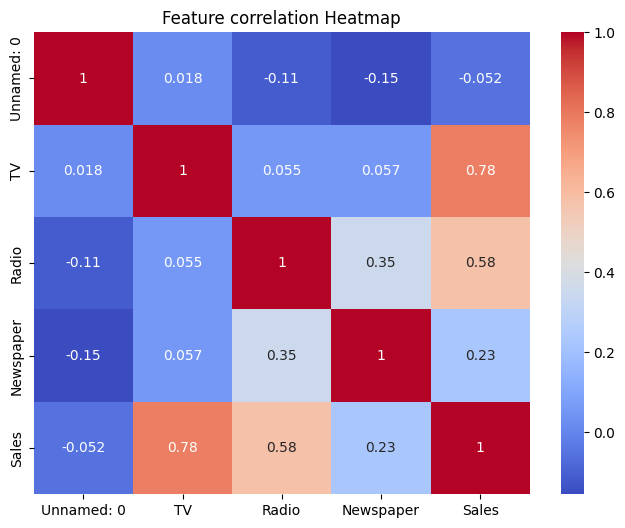

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature correlation Heatmap")
plt.show()

### step 7:tv advertising vs sales

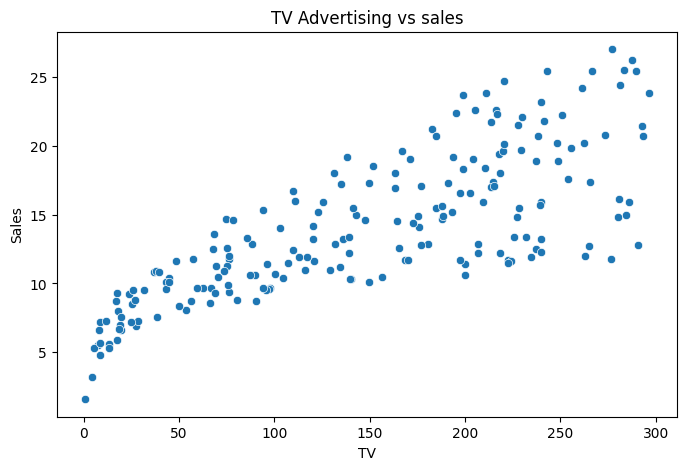

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='TV',
    y='Sales',
    data=df
)

plt.title("TV Advertising vs sales")
plt.show()

### step 8:radio advertising vs sales

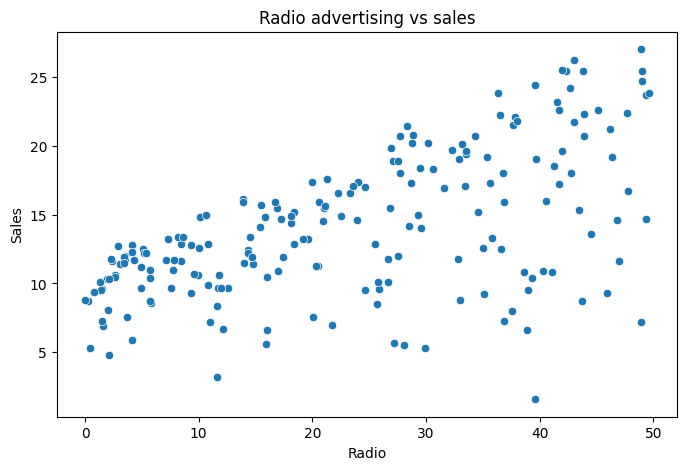

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Radio',
    y='Sales',
    data=df


)

plt.title("Radio advertising vs sales")
plt.show()

### step 9:newspaper advertising vs sales

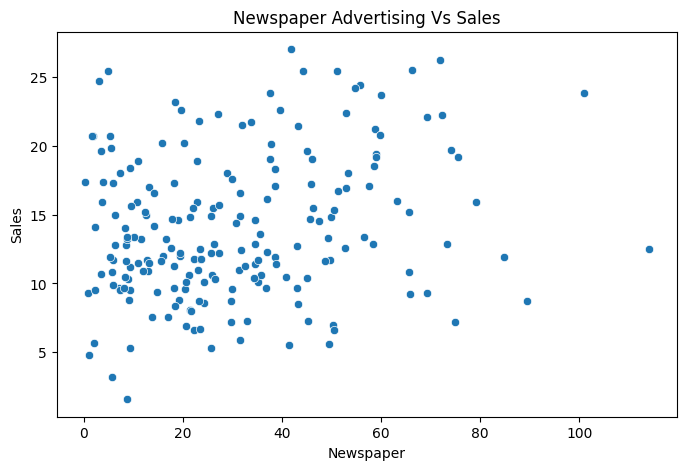

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Newspaper',
    y='Sales',
    data=df
)

plt.title("Newspaper Advertising Vs Sales")
plt.show()

### step 10:prepare features and target

In [16]:
x=df[['TV','Radio','Newspaper']]

y=df['Sales']

### step 11:train-test-split

In [17]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

### step 12:linear regression model

In [19]:
lr=LinearRegression()

lr.fit(x_train,y_train)

lr_pred=lr.predict(x_test)

print("Linear Regression R2 score:",
     r2_score(y_test,lr_pred))

Linear Regression R2 score: 0.899438024100912


### step 13: random forest model

In [20]:
rf=RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train,y_train)

rf_pred=rf.predict(x_test)

print("Random Forest R2 score:",r2_score(y_test,rf_pred))

Random Forest R2 score: 0.9812843792541843


### step 14:model comparsion

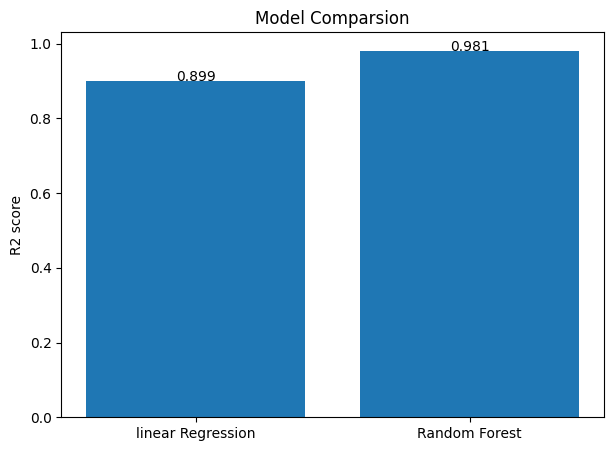

In [23]:
models=[
    "linear Regression",
    "Random Forest"
]

scores=[
    r2_score(y_test,lr_pred),
    r2_score(y_test,rf_pred)
]

plt.figure(figsize=(7,5))

bars=plt.bar(models,scores)

for bar in bars:
    height=bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha='center'
    )

plt.title("Model Comparsion")
plt.ylabel("R2 score")
plt.show()

### step15:actual vs predicted sales

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,rf_pred
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual Vs Predicted Sales")

plt.show()

### step 16:mean absolute error

In [25]:
mae=mean_absolute_error(
    y_test,rf_pred
)

print("Mean Absolute Error:",mae)

Mean Absolute Error: 0.6200999999999988


### step 17:Predict new sales

In [27]:
sample=pd.DataFrame({
    'TV':[230],
    'Radio':[37],
    'Newspaper':[69]
})

prediction=rf.predict(sample)

print("predicted sales:",prediction[0])

predicted sales: 21.915999999999972
